# Plastic Bottle Waste Detection — YOLOv8

Deteksi sampah botol plastik menggunakan **YOLOv8 nano** melalui framework **Ultralytics**.

| Informasi | Detail |
|-----------|--------|
| Model | YOLOv8n (11.2M parameters, mAP@50 ~0.92) |
| Dataset | Plastic Bottle Waste Detection (1 class: `bottle`) |
| Split | Train: 2177 · Valid: 1174 · Test: 648 |
| Hardware | NVIDIA RTX 3050 (6 GB VRAM) |

---

## Tahap 1 — Persiapan Environment

Memastikan semua dependencies terinstall dan GPU terdeteksi dengan benar.

In [1]:
# Install dependencies (jalankan sekali jika belum terinstall)
#!pip install ultralytics opencv-python matplotlib pandas seaborn

In [2]:
import torch
import ultralytics

print(f"Python       : {__import__('sys').version}")
print(f"PyTorch      : {torch.__version__}")
print(f"Ultralytics  : {ultralytics.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ CUDA tidak tersedia — training akan berjalan di CPU (sangat lambat)")

Python       : 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
PyTorch      : 2.6.0+cu124
Ultralytics  : 8.4.75
CUDA available: True
GPU          : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM         : 6.0 GB


---
## Tahap 2 — Persiapan Dataset

Verifikasi struktur dataset, jumlah gambar vs label, dan visualisasi sampel.

In [4]:
import os

dataset_root = "../dataset"
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_root, split, "images")
    lbl_dir = os.path.join(dataset_root, split, "labels")
    img_count = len([f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXT)])
    lbl_count = len([f for f in os.listdir(lbl_dir) if f.lower().endswith('.txt')])
    status = "✅" if img_count == lbl_count else "❌ MISMATCH"
    print(f"{split:5s}: {img_count:5d} images, {lbl_count:5d} labels  {status}")

train:  2177 images,  2177 labels  ✅
valid:  1174 images,  1174 labels  ✅
test :   648 images,   648 labels  ✅


In [5]:
# Cek isi data.yaml
import yaml

with open(os.path.join(dataset_root, "data.yaml"), "r") as f:
    data_cfg = yaml.safe_load(f)

print("Isi data.yaml:")
for k, v in data_cfg.items():
    print(f"  {k}: {v}")

Isi data.yaml:
  train: ./train/images
  val: ./valid/images
  test: ./test/images
  nc: 1
  names: ['bottle']


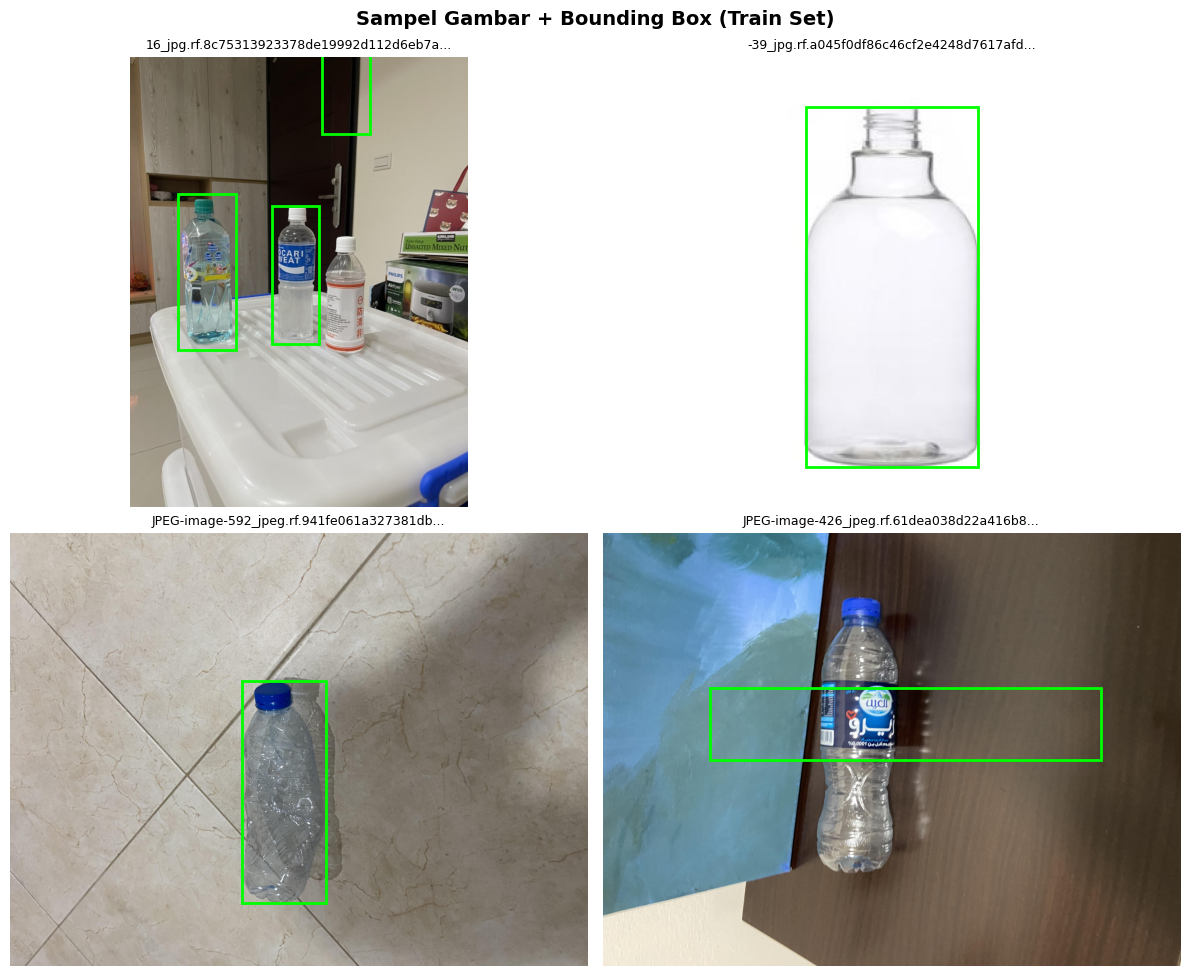

In [6]:
# Visualisasi sampel gambar + bounding box
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

random.seed(42)

split = "train"
img_files = sorted(os.listdir(os.path.join(dataset_root, split, "images")))
samples = random.sample(img_files, 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Sampel Gambar + Bounding Box (Train Set)", fontsize=14, fontweight="bold")

for ax, fname in zip(axes.flat, samples):
    img_path = os.path.join(dataset_root, split, "images", fname)
    lbl_path = os.path.join(dataset_root, split, "labels", os.path.splitext(fname)[0] + ".txt")

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img_rgb)

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2, edgecolor="lime", facecolor="none"
                )
                ax.add_patch(rect)

    ax.set_title(fname[:40] + "...", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

Total objek di train set: 3186
Rata-rata bbox width : 0.349  (std: 0.241)
Rata-rata bbox height: 0.571  (std: 0.291)


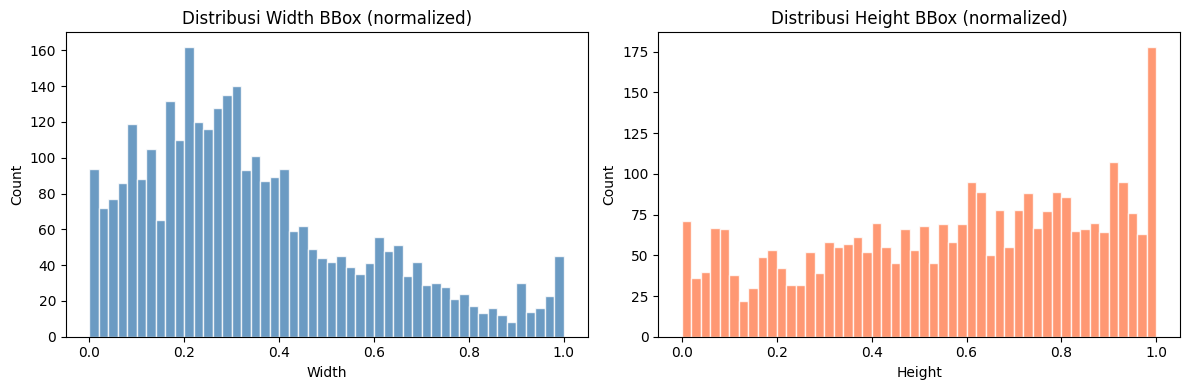

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

widths, heights = [], []
lbl_dir = os.path.join(dataset_root, "train", "labels")

for lbl_file in os.listdir(lbl_dir):
    if not lbl_file.endswith('.txt'): # Skip file selain .txt (jika ada)
        continue
    with open(os.path.join(lbl_dir, lbl_file), "r") as f:
        for line in f:
            parts = line.strip().split()
            # Pastikan baris memiliki minimal 5 kolom (format YOLO standar)
            if len(parts) >= 5:
                try:
                    # Ambil width (index 3) dan height (index 4)
                    bw = float(parts[3])
                    bh = float(parts[4])
                    widths.append(bw)
                    heights.append(bh)
                except ValueError:
                    # Abaikan baris jika ada data yang bukan angka
                    continue

print(f"Total objek di train set: {len(widths)}")
print(f"Rata-rata bbox width : {np.mean(widths):.3f}  (std: {np.std(widths):.3f})")
print(f"Rata-rata bbox height: {np.mean(heights):.3f}  (std: {np.std(heights):.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax1.set_title("Distribusi Width BBox (normalized)")
ax1.set_xlabel("Width")
ax1.set_ylabel("Count")

ax2.hist(heights, bins=50, color="coral", edgecolor="white", alpha=0.8)
ax2.set_title("Distribusi Height BBox (normalized)")
ax2.set_xlabel("Height")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## Tahap 3 — Training Model

Training menggunakan YOLOv8s dengan konfigurasi yang dioptimasi untuk RTX 3050 (6 GB VRAM).

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| model | yolov8n.pt | Pre-trained nano variant |
| epochs | 100 | Dengan early stopping (patience=15) |
| imgsz | 640 | Standar, keseimbangan akurasi vs kecepatan |
| batch | 16 | Muat di VRAM 6 GB |
| device | 0 (GPU) | RTX 3050 |

In [8]:
from ultralytics import YOLO

# Load pre-trained YOLOv8n
model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [10]:
# Training
results = model.train(
    data="../dataset/data.yaml",
    resume=True,
    epochs=100,
    imgsz=640,
    batch=-1,            # DIUBAH: Kunci di 32 (atau 64). Jangan -1 (Auto-batch) karena membuang waktu benchmarking di awal.
    device=0 if torch.cuda.is_available() else "cpu",
    workers=4,           
    patience=30,
    project="./v8n",
    name="train_bottle",
    pretrained=True,
    optimizer="auto",   # DIUBAH: Pakai AdamW langsung agar konvergensi lebih stabil dan cepat dibanding "auto".
    verbose=True,
    seed=42,
    deterministic=False, # DIUBAH: Set ke False agar cuDNN mengaktifkan mode benchmark untuk memilih algoritma tercepat.
    cos_lr=True,         
    lr0=0.01,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    label_smoothing=0.1,
    close_mosaic=15,     
    cache=True,          # DIUBAH: Set ke True (Cache di RAM). RAM 16GB Anda sangat cukup untuk *load* dataset ke memori.
    exist_ok=True,      
)

WARNING model 'yolov8n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.75  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../dataset/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False

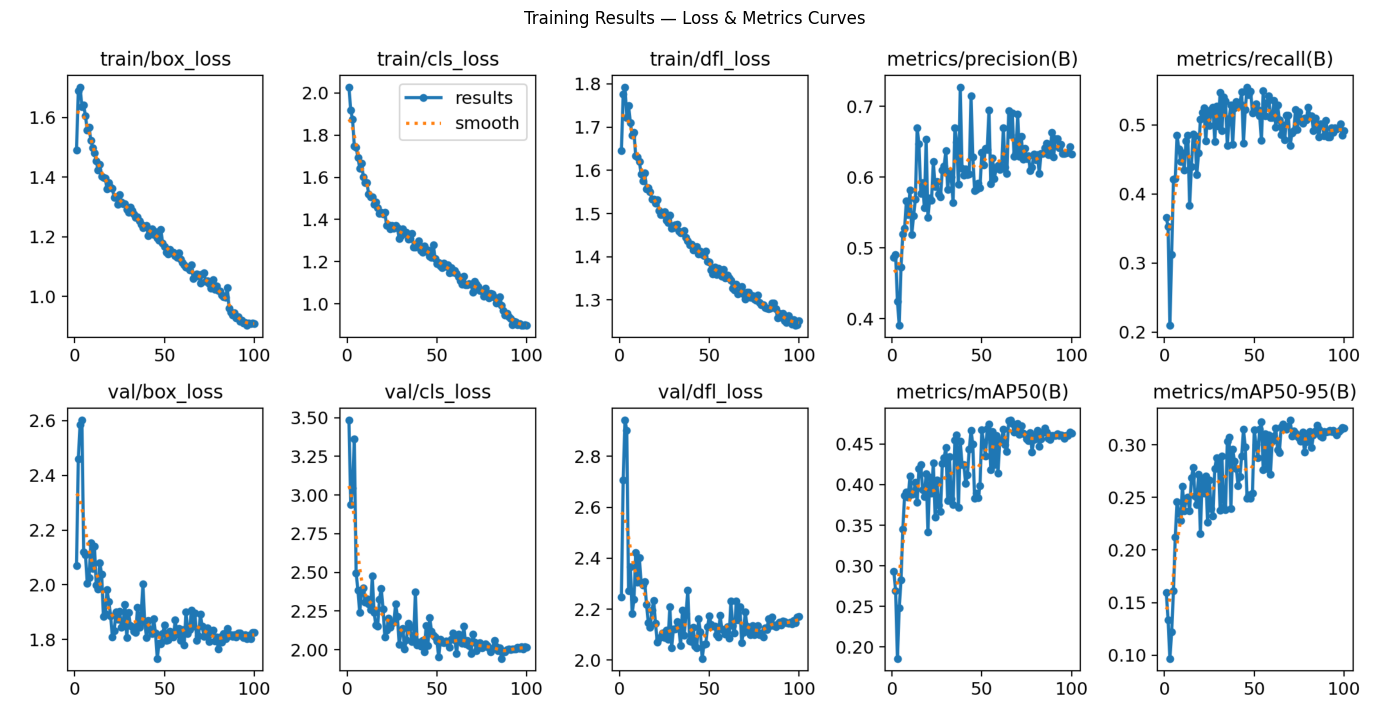

In [12]:
# Tampilkan training loss curves
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_img = mpimg.imread("./runs/detect/v8n/train_bottle/results.png")
plt.figure(figsize=(14, 8))
plt.imshow(results_img)
plt.axis("off")
plt.title("Training Results — Loss & Metrics Curves")
plt.tight_layout()
plt.show()

---
## Tahap 4 — Evaluasi Model

Evaluasi model terbaik pada test set untuk mendapatkan metrik final.

In [13]:
from ultralytics import YOLO

# Load best model
best_model = YOLO("./runs/detect/v8n/train_bottle/weights/best.pt")

# Evaluasi pada test set
metrics = best_model.val(
    data="../dataset/data.yaml", 
    split="test",
    conf=0.001,   # standar COCO eval
    iou=0.6,      # NMS IoU threshold
    plots=True,   # otomatis simpan PR/F1/CM
    )

print("=" * 45)
print("  HASIL EVALUASI — TEST SET")
print("=" * 45)
print(f"  Precision  : {metrics.box.mp:.4f}   (target ≥ 0.85)")
print(f"  Recall     : {metrics.box.mr:.4f}   (target ≥ 0.85)")
print(f"  mAP@50     : {metrics.box.map50:.4f}   (target ≥ 0.90)")
print(f"  mAP@50-95  : {metrics.box.map:.4f}   (target ≥ 0.60)")
print("=" * 45)

Ultralytics 8.4.75  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 58.160.1 MB/s, size: 806.3 KB)
val: Scanning C:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\dataset\test\labels... 648 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 648/648 287.5it/s 2.3s0.1s
val: New cache created: C:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\dataset\test\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 20, len(boxes) = 792. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 3.8it/s 10.7s0.2s
                   all

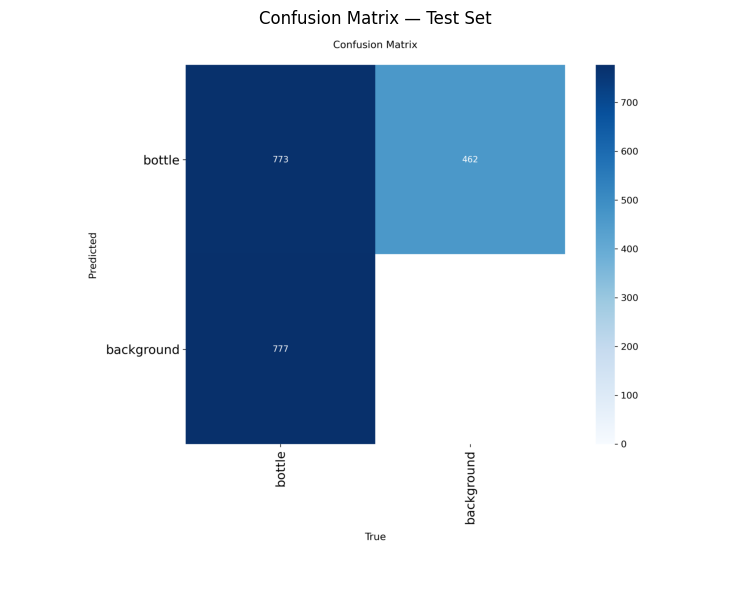

In [14]:
# Tampilkan confusion matrix
import matplotlib.image as mpimg

cm_img = mpimg.imread("./runs/detect/v8n/train_bottle/confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(cm_img)
plt.axis("off")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

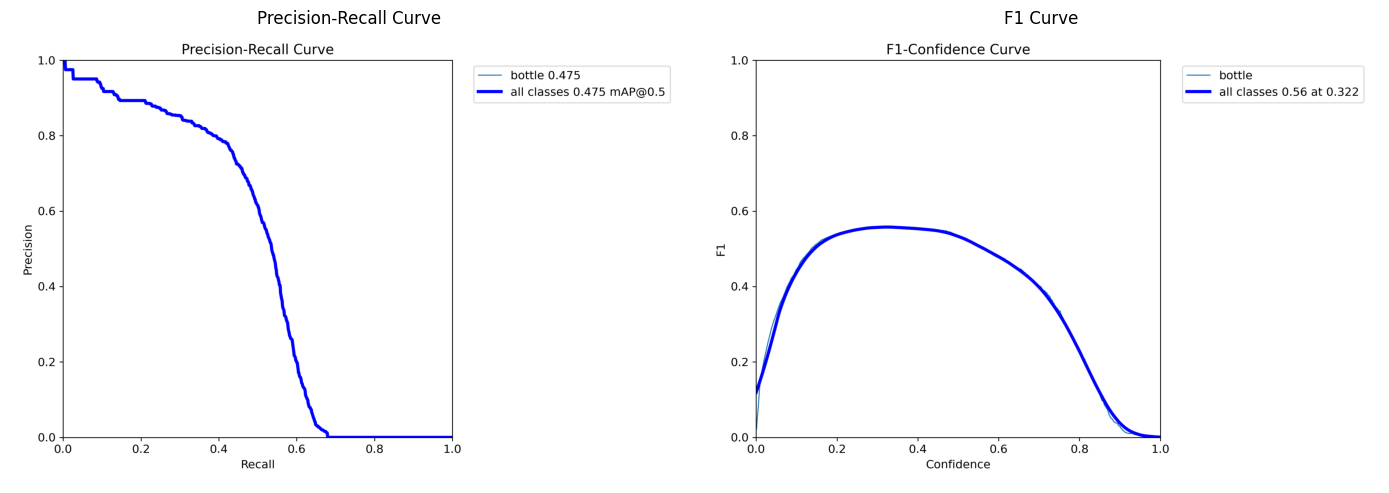

In [17]:
# Tampilkan precision-recall curve dan F1 curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pr_img = mpimg.imread("./runs/detect/v8n/train_bottle/BoxPR_curve.png")
f1_img = mpimg.imread("./runs/detect/v8n/train_bottle/BoxF1_curve.png")

axes[0].imshow(pr_img)
axes[0].set_title("Precision-Recall Curve")
axes[0].axis("off")

axes[1].imshow(f1_img)
axes[1].set_title("F1 Curve")
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## Tahap 5 — Inferensi & Implementasi

Menggunakan model terbaik untuk deteksi pada gambar, video, dan webcam.

In [18]:
# Load best model untuk inferensi
model = YOLO("./runs/detect/v8n/train_bottle/weights/best.pt")

### 5.1 Deteksi pada Gambar

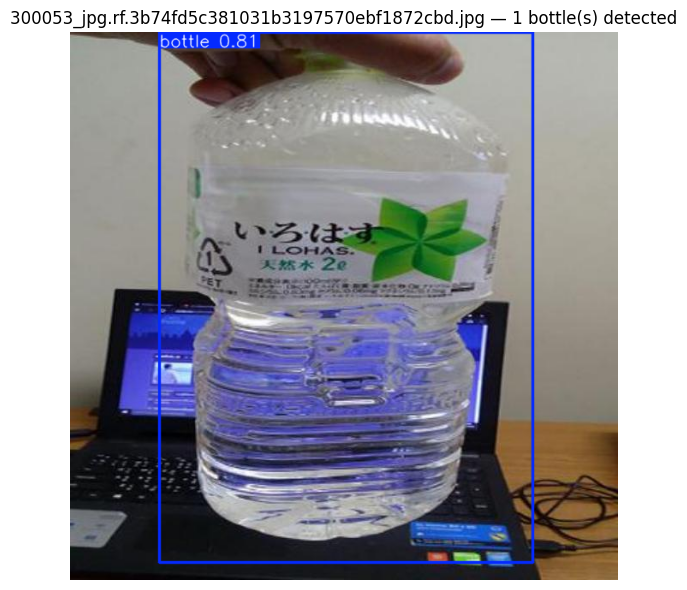

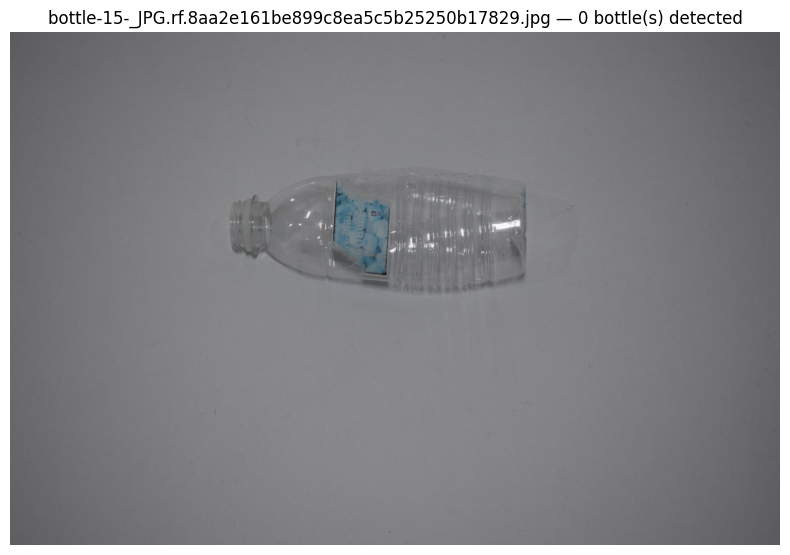

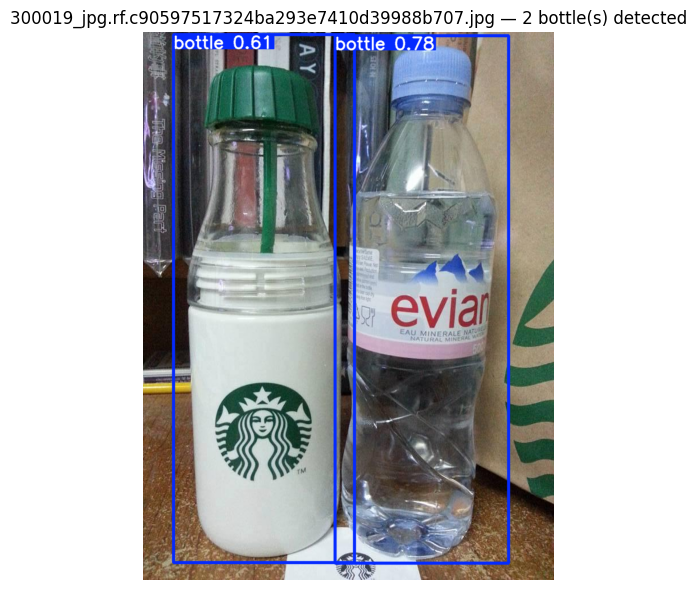

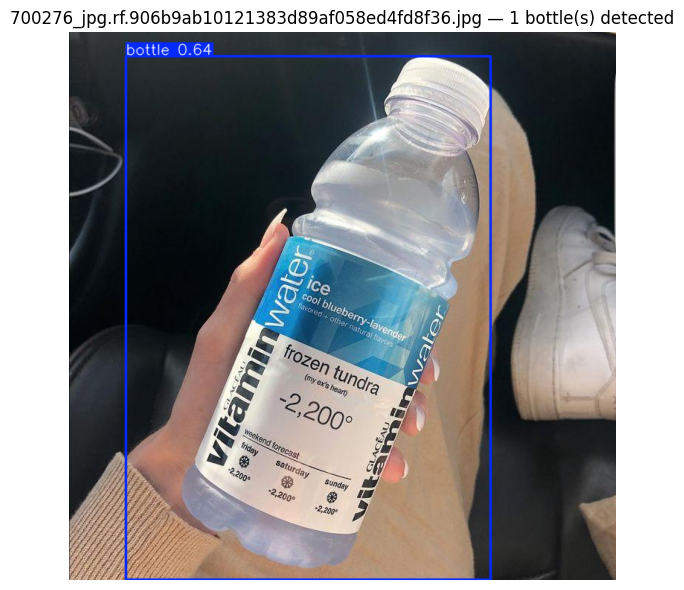

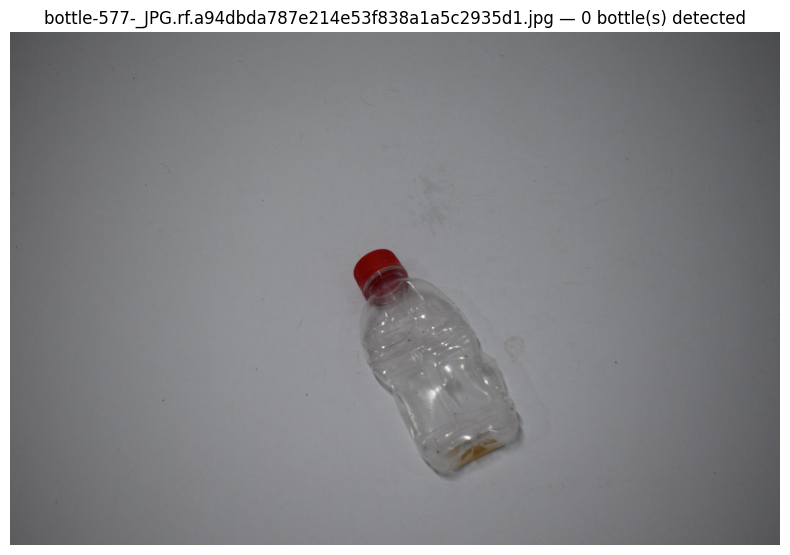

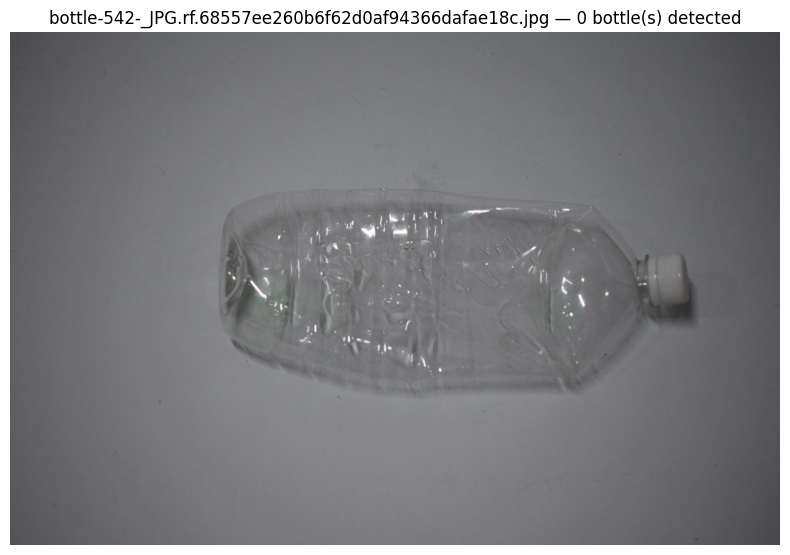

In [24]:
import os
import random

# Ambil beberapa gambar acak dari test set untuk demo
test_img_dir = "../dataset/test/images"
test_images = sorted(os.listdir(test_img_dir))
demo_images = random.sample(test_images, min(6, len(test_images)))

for img_name in demo_images:
    img_path = os.path.join(test_img_dir, img_name)
    results = model.predict(source=img_path, conf=0.5, save=False, verbose=False)

    # Tampilkan hasil
    annotated = results[0].plot()  # BGR image with annotations
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    n_detections = len(results[0].boxes)
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_rgb)
    plt.title(f"{img_name} — {n_detections} bottle(s) detected")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [21]:
# Deteksi batch pada seluruh test set — simpan hasilnya
results = model.predict(
    source="../dataset/test/images",
    conf=0.5,
    save=True,
    project="../runs/detect",
    name="predict_test_set",
    verbose=True,
)

print(f"\nTotal gambar diproses: {len(results)}")
total_bottles = sum(len(r.boxes) for r in results)
print(f"Total botol terdeteksi: {total_bottles}")


image 1/648 c:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\notebook\..\dataset\test\images\-136_jpg.rf.b58c092e504d1e1f0bb5d5cbf60ad415.jpg: 640x480 2 bottles, 61.0ms
image 2/648 c:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\notebook\..\dataset\test\images\-171_jpg.rf.513b40a00a8128949d034c41662c0c59.jpg: 480x640 (no detections), 67.5ms
image 3/648 c:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\notebook\..\dataset\test\images\-18_jpg.rf.9e168f61ceff6dcd69f8e65369745459.jpg: 480x640 1 bottle, 51.8ms
image 4/648 c:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\notebook\..\dataset\test\images\-216_jpg.rf.41406aa65c99402c41e2d3d03f670476.jpg: 480x640 1 bottle, 51.5ms
image 5/648 c:\Users\jeebr\Documents\Projects\plastic bottle waste detection YOLO\notebook\..\dataset\test\images\-253_jpg.rf.8ee591edcfd2f79c5b88f85d886925ac.jpg: 640x640 1 bottle, 12.2ms
image 6/648 c:\Users\jeebr\Documents\Projects\p

### 5.2 Deteksi pada Video

> **Catatan:** Siapkan file video di path yang sesuai, atau gunakan webcam sebagai sumber video.

In [ ]:
# Deteksi pada video (ubah path sesuai file video yang tersedia)
# video_path = "path/to/video.mp4"  # <-- Ganti dengan path video Anda

# results = model.predict(
#     source=video_path,
#     conf=0.5,
#     save=True,
#     project="../runs/detect",
#     name="predict_video",
# )

print("Untuk menjalankan deteksi video:")
print("1. Uncomment kode di atas")
print("2. Ganti video_path dengan path file video Anda")
print("3. Jalankan cell")

### 5.3 Deteksi Real-time via Webcam

In [22]:
import cv2
from ultralytics import YOLO

model = YOLO("./runs/detect/v8n/train_bottle/weights/best.pt")

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("❌ Tidak bisa membuka webcam")
else:
    print("🎥 Webcam aktif — tekan 'q' untuk keluar")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Deteksi
        results = model.predict(source=frame, conf=0.5, verbose=False)

        # Ambil frame yang sudah dianotasi
        annotated_frame = results[0].plot()

        # Hitung jumlah botol terdeteksi
        n_bottles = len(results[0].boxes)

        # Tampilkan counter di frame
        cv2.putText(
            annotated_frame,
            f"Bottles: {n_bottles}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
        )

        cv2.imshow("Plastic Bottle Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam ditutup.")

🎥 Webcam aktif — tekan 'q' untuk keluar
Webcam ditutup.


### 5.4 Export Model

Export model ke format ONNX agar bisa dijalankan di perangkat tanpa GPU / untuk deployment.

In [23]:
# Export ke ONNX format
model = YOLO("./runs/detect/v8n/train_bottle/weights/best.pt")

model.export(
    format="onnx",
    imgsz=640,
    simplify=True,
    dynamic=True,   # ← mendukung dynamic batch size
    opset=14,       # ← kompatibilitas lebih luas
    half=False,     # set True jika target mendukung FP16

)

print("✅ Model berhasil di-export ke format ONNX")

Ultralytics 8.4.75  Python-3.12.0 torch-2.6.0+cu124 CPU (Intel Core 5 210H)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs\detect\v8n\train_bottle\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.0 environment at: c:\Users\jeebr\AppData\Local\Programs\Python\Python312
Resolved 12 packages in 1.15s
 Downloaded onnxruntime
 Downloaded onnx
Prepared 3 packages in 11.97s
Installed 3 packages in 6.45s
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success  24.1s
WARNING requirements: Restart runtime or rerun command for updates to take effect


ONNX: start

---
## Ringkasan

| Tahap | Status | Output |
|-------|--------|--------|
| 1. Persiapan Environment | ✅ | Python, PyTorch, Ultralytics YOLOv8 |
| 2. Persiapan Dataset | ✅ | Dataset terverifikasi (2177/1174/648) |
| 3. Training Model | ✅ | Best weights: `runs/detect/train_bottle/weights/best.pt` |
| 4. Evaluasi Model | ✅ | Precision, Recall, mAP@50, mAP@50-95 |
| 5. Inferensi | ✅ | Deteksi gambar, video, webcam + export ONNX |